In [1]:
import torch
print(torch.cuda.is_available())        # doit afficher True
print(torch.cuda.get_device_name(0))    # doit afficher quelque chose comme "Tesla T4"

True
Tesla T4


In [2]:
!pip install transformers datasets accelerate -q

In [3]:
import pandas as pd
from datasets import load_dataset

print("Chargement du dataset...")
dataset = load_dataset("tblard/allocine")

# Conversion en DataFrames
train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])

# Sous-échantillonnage — 10k train, 2k val, 2k test
# (suffisant pour fine-tuner, raisonnable pour Colab gratuit)
train_sample = train_df.groupby("label").sample(5000, random_state=42).reset_index(drop=True)
val_sample   = val_df.groupby("label").sample(1000, random_state=42).reset_index(drop=True)
test_sample  = test_df.groupby("label").sample(1000, random_state=42).reset_index(drop=True)

print(f"✅ Train : {len(train_sample):,} reviews")
print(f"✅ Val   : {len(val_sample):,} reviews")
print(f"✅ Test  : {len(test_sample):,} reviews")
print(f"\nDistribution train :\n{train_sample['label'].value_counts()}")

Chargement du dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.31k [00:00<?, ?B/s]

allocine/train-00000-of-00001.parquet:   0%|          | 0.00/60.0M [00:00<?, ?B/s]

allocine/validation-00000-of-00001.parqu(…):   0%|          | 0.00/7.58M [00:00<?, ?B/s]

allocine/test-00000-of-00001.parquet:   0%|          | 0.00/7.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

✅ Train : 10,000 reviews
✅ Val   : 2,000 reviews
✅ Test  : 2,000 reviews

Distribution train :
label
0    5000
1    5000
Name: count, dtype: int64


In [4]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset

# Chargement du tokenizer CamemBERT
tokenizer = AutoTokenizer.from_pretrained("camembert-base")
print("✅ Tokenizer chargé")

# Classe Dataset PyTorch
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

# Création des datasets
print("Tokenisation en cours...")
train_dataset = ReviewDataset(
    train_sample["review"].tolist(),
    train_sample["label"].tolist(),
    tokenizer
)
val_dataset = ReviewDataset(
    val_sample["review"].tolist(),
    val_sample["label"].tolist(),
    tokenizer
)
test_dataset = ReviewDataset(
    test_sample["review"].tolist(),
    test_sample["label"].tolist(),
    tokenizer
)

print(f"✅ Tokenisation terminée")
print(f"   Train  : {len(train_dataset)} exemples")
print(f"   Val    : {len(val_dataset)} exemples")
print(f"   Test   : {len(test_dataset)} exemples")

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

✅ Tokenizer chargé
Tokenisation en cours...
✅ Tokenisation terminée
   Train  : 10000 exemples
   Val    : 2000 exemples
   Test   : 2000 exemples


In [5]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Chargement du modèle CamemBERT avec une tête de classification
model = AutoModelForSequenceClassification.from_pretrained(
    "camembert-base",
    num_labels=2
)
print("✅ Modèle chargé")

# Fonction de métriques
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

# Configuration de l'entraînement
training_args = TrainingArguments(
    output_dir="./camembert-allocine",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    fp16=True,              # accélération GPU
    report_to="none"        # désactive wandb
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("🚀 Démarrage du fine-tuning...")
trainer.train()
print("✅ Fine-tuning terminé !")

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle chargé
🚀 Démarrage du fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.189911,0.180015,0.939000,0.938902
2,0.108235,0.135690,0.957000,0.957000
3,0.065610,0.150528,0.956500,0.956497


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Fine-tuning terminé !


Évaluation sur le test set...



📊 Accuracy CamemBERT — Test set : 0.9590 (95.90%)

📋 Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.96      0.96      0.96      1000
     Positif       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



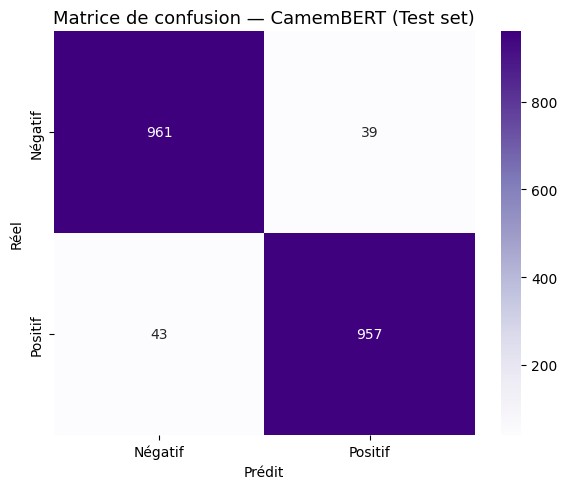


   COMPARAISON FINALE
  TF-IDF + Logistic Regression : 93.53%
  CamemBERT fine-tuné          : 95.90%
  Gain Transformers            : +2.37%


In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Évaluation sur le test set
print("Évaluation sur le test set...")
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_sample["label"].tolist()

acc_camembert = accuracy_score(y_true, y_pred)
print(f"\n📊 Accuracy CamemBERT — Test set : {acc_camembert:.4f} ({acc_camembert*100:.2f}%)")
print("\n📋 Rapport de classification :")
print(classification_report(y_true, y_pred, target_names=["Négatif", "Positif"]))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Négatif", "Positif"],
            yticklabels=["Négatif", "Positif"])
plt.title("Matrice de confusion — CamemBERT (Test set)", fontsize=13)
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("confusion_matrix_camembert.png")
plt.show()

# Comparaison finale
print("\n" + "="*45)
print("   COMPARAISON FINALE")
print("="*45)
print(f"  TF-IDF + Logistic Regression : 93.53%")
print(f"  CamemBERT fine-tuné          : {acc_camembert*100:.2f}%")
print(f"  Gain Transformers            : +{(acc_camembert - 0.9353)*100:.2f}%")
print("="*45)